In [13]:
import os
import pickle
from tqdm import tqdm
import numpy as np

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical,plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add




In [14]:
!pip install pillow




[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
!pip install tqdm


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
# small library for seeing the progress of loops.
from tqdm import tqdm
tqdm().pandas()

0it [00:00, ?it/s]


In [18]:
# Set these path according to project folder in you system
BASE_DIR = r'C:\Users\HP\Downloads\image_captioning_prroject\flickr'
WORKING_DIR = r'C:\Users\HP\Downloads\image_captioning_prroject\flickr\working'


In [19]:
#EXTRACT IMAGE FEATURES USING VGG16 MODEL
model=VGG16()
#RESTRUCTURE THE MODEL
model=Model(inputs=model.inputs,outputs=model.layers[-2].output)#WER DONOT WANT THE LAST LAYER
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [20]:
features={}
directory=os.path.join(BASE_DIR,'Images')
for img_name in tqdm(os.listdir(directory)):
    img_path=os.path.join(directory,img_name)
    img_path=directory+'/'+img_name
    image=load_img(img_path,target_size=(224,224))
    image=img_to_array(image)
    image=image.reshape((1,image.shape[0],image.shape[1],image.shape[2]))
    image=preprocess_input(image)
    feature=model.predict(image,verbose=0)
    img_id=img_name.split('.')[0]
    #store feature
    features[img_id]=feature
    

100%|██████████| 8091/8091 [1:26:48<00:00,  1.55it/s]  


In [22]:
import os
import pickle

# Make sure WORKING_DIR exists
WORKING_DIR = r"C:\Users\HP\Downloads\image_captioning_prroject\flickr\working"
os.makedirs(WORKING_DIR, exist_ok=True)  # Creates the folder if it doesn't exist

# Save features
pickle.dump(features, open(os.path.join(WORKING_DIR, 'features.pkl'), 'wb'))


In [23]:
#LOAD THE CAPTIONS
with open(os.path.join(BASE_DIR,'captions.txt'),'r') as f:
    next(f)#SKIP THE FIRST LINE 
    captions_doc=f.read()
    
    

In [24]:
#creatre a mapping of image id to captions
mapping={}
for line in tqdm(captions_doc.split('\n')):
    #splittheline by comma
    tokens=line.split(',')
    if len(line)<2:
        continue
    img_id,caption=tokens[0],tokens[1:]
    #remove extension from image id
    img_id=img_id.split('.')[0]
    #convert caption list to string
    caption=' '.join(caption)
    #create list if needed
    if img_id not in mapping:
        mapping[img_id]=[]
    mapping[img_id].append(caption)

100%|██████████| 40456/40456 [00:00<00:00, 536508.50it/s]


In [25]:
len(mapping)  #number of images in the dataset

8091

In [27]:
#CLEAN THE CAPTIONS
def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption=captions[i]
            #convert to lower case
            caption=caption.lower()
            #remove punctuation
            caption=caption.replace('[^a-zA-Z]',' ')
            #delete additional spaces
            caption=caption.replace('\s+',' ')
            #add start and end tokens to the caption
            caption='<start> ' + " ".join([word for word in caption.split() if len(word)>1]) + ' <end>'
            captions[i]=caption
            

In [29]:
mapping["1000268201_693b08cb0e"]

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

In [30]:
#preprocess the captions
clean(mapping)

In [31]:
mapping["1000268201_693b08cb0e"]

['<start> child in pink dress is climbing up set of stairs in an entry way <end>',
 '<start> girl going into wooden building <end>',
 '<start> little girl climbing into wooden playhouse <end>',
 '<start> little girl climbing the stairs to her playhouse <end>',
 '<start> little girl in pink dress going into wooden cabin <end>']

In [32]:
all_captions=[]
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)

In [33]:
len(all_captions)  #total number of captions

40455

In [34]:
all_captions[:10]  #first 10 captions

['<start> child in pink dress is climbing up set of stairs in an entry way <end>',
 '<start> girl going into wooden building <end>',
 '<start> little girl climbing into wooden playhouse <end>',
 '<start> little girl climbing the stairs to her playhouse <end>',
 '<start> little girl in pink dress going into wooden cabin <end>',
 '<start> black dog and spotted dog are fighting <end>',
 '<start> black dog and tri-colored dog playing with each other on the road <end>',
 '<start> black dog and white dog with brown spots are staring at each other in the street <end>',
 '<start> two dogs of different breeds looking at each other on the road <end>',
 '<start> two dogs on pavement moving toward each other <end>']

In [105]:
#tokenize the text
tokenizer=Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size=len(tokenizer.word_index)+1
vocab_size  #size of vocabulary


8483

In [36]:
#get maximum length of caption
max_length=max(len(caption.split()) for caption in all_captions)

In [37]:
max_length  #maximum length of caption

35

In [70]:
#train test split
img_ids=list(mapping.keys())
split=int(0.9*len(img_ids))
train_img_ids=img_ids[:split]
test_img_ids=img_ids[split:]
len(train_img_ids), len(test_img_ids)
#(number of training images, number of testing images)




(7281, 810)

In [ ]:
#<start> a dog is running in the grass <end>
#x             y
#<start>        a 
#<start> a     dog
#<start> a dog  is
#<start> a dog is running


In [71]:
#DATA GENERATOR to yield batches of data to avoid session crash
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    """
    Generator for image captioning.
    Yields batches of ([image_features, input_sequences], target_words)
    """
    X1, X2, y = [], [], []
    n = 0

    while True:
        for key in data_keys:
            captions = mapping[key]      # list of captions for this image
            feature = features[key][0]   # image feature vector

            for caption in captions:
                # Convert caption to sequence of integers
                seq = tokenizer.texts_to_sequences([caption])[0]

                # Create input-output pairs
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]

                    # Pad input sequence
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]

                    # One-hot encode output word
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    # Store in batch
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)
                    n += 1

                    # Yield batch when reached batch_size
                    if n == batch_size:
                        yield (np.array(X1), np.array(X2)), np.array(y)
                        X1, X2, y = [], [], []
                        n = 0


In [74]:
#Encoder model 
#image feature layer
inputs1=Input(shape=(4096,))#image feature input    
fe1=Dropout(0.5)(inputs1)
fe2=Dense(256,activation='relu')(fe1)# layers ar3e connected sequentially
#sequence feature layer
inputs2=Input(shape=(max_length,))#caption input
se1=Embedding(vocab_size,256,mask_zero=True)(inputs2)#mask_zero=True because we are using padding
se2=Dropout(0.5)(se1)
se3=LSTM(256)(se2)
#decoder model  for concatenating both image and caption features
decoder1 =add([fe2,se3])
decoder2=Dense(256,activation='relu')(decoder1)
outputs=Dense(vocab_size,activation='softmax')(decoder2)

model=Model(inputs=[inputs1,inputs2],outputs=outputs)#final model for training
model.compile(loss='categorical_crossentropy',optimizer='adam')
model.summary()



Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_16      │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 35, 256)   │  2,171,648 │ input_layer_17[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 4096)      │          0 │ input_layer_16[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 35, 256)   │          0 │ embedding_7[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, 35)        │          0 │ input_layer_17[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 256)       │  1,048,832 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 256)       │    525,312 │ dropout_15[0][0], │
│                     │                   │            │ not_equal_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 256)       │          0 │ dense_20[0][0],   │
│                     │                   │            │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 256)       │     65,792 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 8483)      │  2,180,131 │ dense_21[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,991,715 (22.86 MB)

 Trainable params: 5,991,715 (22.86 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
!pip install pydot


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [75]:
epochs = 15
batch_size = 64
steps = len(train_img_ids) // batch_size

for i in range(epochs):
    # Create generator for this epoch
    generator = data_generator(train_img_ids, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    
    # Train for 1 epoch
    model.fit(generator,
              epochs=1,
              steps_per_epoch=steps,
              verbose=1)
    
 


113/113 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - loss: 6.4248
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - loss: 5.2669
113/113 ━━━━━━━━━━━━━━━━━━━━ 19s 166ms/step - loss: 4.8069
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - loss: 4.4400
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 159ms/step - loss: 4.0979
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 159ms/step - loss: 3.7678
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - loss: 3.4697
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 163ms/step - loss: 3.2070
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - loss: 2.9834
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 161ms/step - loss: 2.7873
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 151ms/step - loss: 2.7124
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - loss: 2.5438
113/113 ━━━━━━━━━━━━━━━━━━━━ 19s 164ms/step - loss: 2.3883
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 151ms/step - loss: 2.2741
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 162ms/step - loss: 2.1012


In [76]:
model.save('final_image_captioning_model.h5')

In [77]:
#generate caption for an image
def idx_to_word(integer,tokenizer):
    for word,index in tokenizer.word_index.items():
        if index==integer:
            return word
    return None 

In [78]:
#GENERATE CAPTION FOR AN IMAGE
def predict_caption(model, image_feature, tokenizer, max_length):
    in_text='<start>'
    #iterate over the max length of caption
    for i in range(max_length):
        #encode input sequence
        sequence=tokenizer.texts_to_sequences([in_text])[0]
        sequence=pad_sequences([sequence],maxlen=max_length)#for fixed length input
        #predict next word
        yhat=model.predict([image_feature,sequence],verbose=0)
        #get index with highes probability
        yhat=np.argmax(yhat)
        word=idx_to_word(yhat,tokenizer)
        if word is None:
            break
        #APPEND THE PREDICTED WORD TO INPUT TEXT TO CRERATE THE INPUT OUTPUT SEQUENCE
        in_text+=' '+word
        if word=='<end>':#we reached at the end of the caption
            break
    return in_text

In [79]:
#VALIDATE WITH A TEST IMAGE
from nltk.translate.bleu_score import corpus_bleu
actual, predicted = [], []
for key in tqdm(test_img_ids):
    captions = mapping[key]
    #predict caption
    y_pred = predict_caption(model, features[key], tokenizer, max_length)#feature[key] is the image feature
    #split actual captions into words
    actual_captions = [caption.split() for caption in captions]#list of actual captions
    #append to the lists
    actual.append(actual_captions)
    predicted.append(y_pred.split())
#calculate BLEU score
print('BLEU-1: %f' % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print('BLEU-2: %f' % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))



100%|██████████| 810/810 [1:20:36<00:00,  5.97s/it]


BLEU-1: 0.122737
BLEU-2: 0.063963


In [91]:
from PIL import Image
import matplotlib.pyplot as plt
#FUNCTION TO DISPLAY IMAGE WITH CAPTION
def display_image_caption(image_name):
    """
    Display the image, print its true captions, and predicted caption.

    Parameters:
    - image_name: str, filename of the image (e.g., '123.jpg')
    - model: trained captioning model
    - features: dictionary of extracted image features
    - tokenizer: tokenizer for text sequences
    - max_length: maximum length of caption sequences
    - mapping: dictionary of true captions for images
    - BASE_DIR: base directory where the 'Images' folder is located
    """
    # i want only one best caption for the image
    
    # Load the image
    image_path = os.path.join(BASE_DIR, 'Images', image_name)
    image = Image.open(image_path)
    
    # Get the image ID (assuming filename format: '123.jpg')
    image_id = image_name.split('.')[0]

    # Print all true captions for this image
    if image_id in mapping:
        print("True Captions:")
        for cap in mapping[image_id]:
            print('-', cap)
    else:
        print("No true captions found for this image.")

    # Predict caption using the model
    if image_id in features:
        y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
        print('Predicted Caption:', y_pred[0])#print only one best caption
    else:
        print("No extracted features found for this image. Cannot predict caption.")

    # Display the image
    plt.imshow(image)
    plt.axis('off')
    plt.show()

#TEST THE FUNCTION WITH AN IMAGE
    
    



True Captions:
- <start> child in pink dress is climbing up set of stairs in an entry way <end>
- <start> girl going into wooden building <end>
- <start> little girl climbing into wooden playhouse <end>
- <start> little girl climbing the stairs to her playhouse <end>
- <start> little girl in pink dress going into wooden cabin <end>
Predicted Caption: <


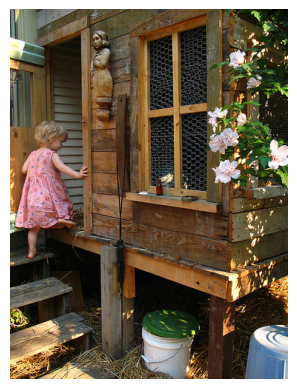

In [92]:
display_image_caption('1000268201_693b08cb0e.jpg')

True Captions:
- <start> black dog and spotted dog are fighting <end>
- <start> black dog and tri-colored dog playing with each other on the road <end>
- <start> black dog and white dog with brown spots are staring at each other in the street <end>
- <start> two dogs of different breeds looking at each other on the road <end>
- <start> two dogs on pavement moving toward each other <end>
Predicted Caption: <


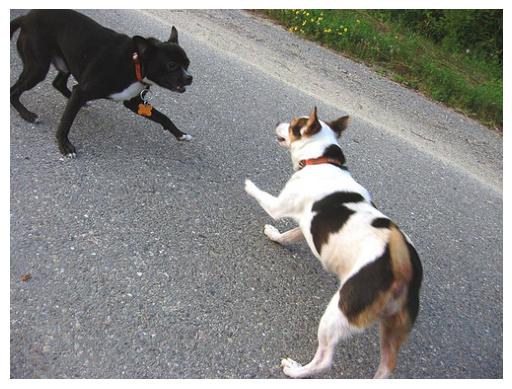

True Captions:
- <start> little girl covered in paint sits in front of painted rainbow with her hands in bowl <end>
- <start> little girl is sitting in front of large painted rainbow <end>
- <start> small girl in the grass plays with fingerpaints in front of white canvas with rainbow on it <end>
- <start> there is girl with pigtails sitting in front of rainbow painting <end>
- <start> young girl with pigtails painting outside in the grass <end>
Predicted Caption: <


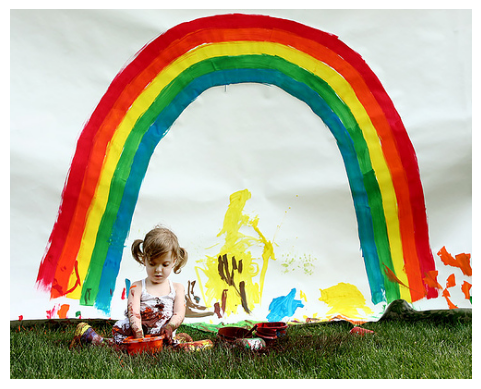

True Captions:
- <start> man lays on bench while his dog sits by him <end>
- <start> man lays on the bench to which white dog is also tied <end>
- <start> man sleeping on bench outside with white and black dog sitting next to him <end>
- <start> shirtless man lies on park bench with his dog <end>
- <start> man laying on bench holding leash of dog sitting on ground <end>
Predicted Caption: <


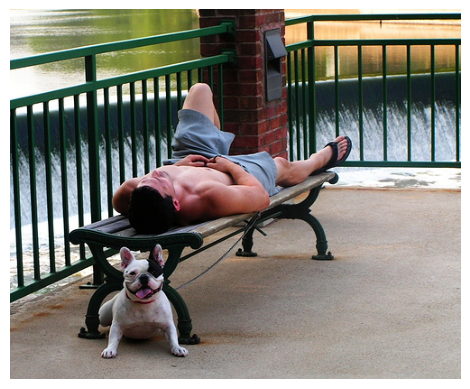

In [115]:
#check 5 more images
display_image_caption('1001773457_577c3a7d70.jpg')
display_image_caption('1002674143_1b742ab4b8.jpg')
display_image_caption('1003163366_44323f5815.jpg')



In [107]:
#save tokenizer with pickle
with open(os.path.join(WORKING_DIR,'tokenizer.pkl'),'wb') as f:
    pickle.dump(tokenizer,f)
#save vocab size and max length
with open(os.path.join(WORKING_DIR,'vocab_maxlength.pkl'),'wb') as f:
    pickle.dump((vocab_size,max_length),f)
    